In [2]:
import torch
from torch import nn
import matplotlib.pyplot as plt

import os
import sys
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.data.data import get_ds

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [13]:
class Encoder(nn.Module):
    def __init__(self, seq_len, no_features, embedding_size):
        super().__init__()
        
        self.seq_len = seq_len
        self.no_features = no_features    # The number of expected features(= dimension size) in the input x
        self.embedding_size = embedding_size   # the number of features in the embedded points of the inputs' number of features
        self.hidden_size = (2 * embedding_size)  # The number of features in the hidden state h
        self.LSTM1 = nn.LSTM(
            input_size = no_features,
            hidden_size = embedding_size,
            num_layers = 1,
            batch_first=True
        )
        
    def forward(self, x):
        # Inputs: input, (h_0, c_0). -> If (h_0, c_0) is not provided, both h_0 and c_0 default to zero.
        x, (hidden_state, cell_state) = self.LSTM1(x)  
        last_lstm_layer_hidden_state = hidden_state[-1,:,:]
        return last_lstm_layer_hidden_state

class Decoder(nn.Module):
    def __init__(self, seq_len, no_features, output_size):
        super().__init__()

        self.seq_len = seq_len
        self.no_features = no_features
        self.hidden_size = (2 * no_features)
        self.output_size = output_size
        self.LSTM1 = nn.LSTM(
            input_size = no_features,
            hidden_size = self.hidden_size,
            num_layers = 1,
            batch_first = True
        )

        self.fc = nn.Linear(self.hidden_size, output_size)
        
    def forward(self, x):
        x = x.unsqueeze(1).repeat(1, self.seq_len, 1)
        x, (hidden_state, cell_state) = self.LSTM1(x)
        x = x.reshape((-1, self.seq_len, self.hidden_size))
        out = self.fc(x)
        return out

class LSTM_AE(nn.Module):
    def __init__(self, seq_len, no_features, embedding_dim, learning_rate, every_epoch_print, epochs, patience, max_grad_norm):
        super().__init__()
        
        self.seq_len = seq_len
        self.no_features = no_features
        self.embedding_dim = embedding_dim

        self.encoder = Encoder(self.seq_len, self.no_features, self.embedding_dim)
        self.decoder = Decoder(self.seq_len, self.embedding_dim, self.no_features)
        
        self.epochs = epochs
        self.learning_rate = learning_rate
        self.patience = patience
        self.max_grad_norm = max_grad_norm
        self.every_epoch_print = every_epoch_print
    
    def forward(self, x):
        torch.manual_seed(0)
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded
    
    def fit(self, x):
        """
        trains the model's parameters over a fixed number of epochs, specified by `n_epochs`, as long as the loss keeps decreasing.
        :param dataset: `Dataset` object
        :param bool save: If true, dumps the trained model parameters as pickle file at `dload` directory
        :return:
        """
        optimizer = torch.optim.Adam(self.parameters(), lr = self.learning_rate)
        criterion = nn.MSELoss(reduction='mean')
        self.train()
        # initialize the early_stopping object
        # early_stopping = EarlyStopping(patience=self.patience, verbose=False)

        for epoch in range(1 , self.epochs+1):
            # updating early_stopping's epoch
            # early_stopping.epoch = epoch        
            optimizer.zero_grad()
            encoded, decoded = self(x)
            loss = criterion(decoded , x)
            
            # early_stopping needs the validation loss to check if it has decresed, 
            # and if it has, it will make a checkpoint of the current model
            # early_stopping(loss, self)
            
            # if early_stopping.early_stop:
                # break
            
            # Backward pass
            loss.backward()
            # nn.utils.clip_grad_norm_(self.parameters(), max_norm = self.max_grad_norm)
            optimizer.step()
            
            if epoch % self.every_epoch_print == 0:
                print(f"epoch : {epoch}, loss_mean : {loss.item():.7f}")
        
        # load the last checkpoint with the best model
        # self.load_state_dict(torch.load('./checkpoint.pt'))
        
        # to check the final_loss
        encoded, decoded = self(x)
        final_loss = criterion(decoded , x).item()
        
        return final_loss
    
    def encode(self, x):
        self.eval()
        encoded = self.encoder(x)
        return encoded
    
    def decode(self, x):
        self.eval()
        decoded = self.decoder(x)
        squeezed_decoded = decoded.squeeze()
        return squeezed_decoded
    
    def load(self, PATH):
        """
        Loads the model's parameters from the path mentioned
        :param PATH: Should contain pickle file
        :return: None
        """
        self.is_fitted = True
        self.load_state_dict(torch.load(PATH))

    

In [14]:
class_to_index={"standing":0, "running":1, "walking":2,"badminton":3}

train_ds, test_ds = get_ds("/Users/bhaveshkalisetti/Desktop/mmbs/data/basicmotions/BasicMotions_TRAIN.ts", class_to_index), get_ds("/Users/bhaveshkalisetti/Desktop/mmbs/data/basicmotions/BasicMotions_TEST.ts", class_to_index)
len(train_ds)

40

In [15]:
autoencoder = LSTM_AE(
    seq_len=100,
    no_features=1,
    embedding_dim=10,
    learning_rate=0.01,
    every_epoch_print=10,
    epochs=2000,
    patience=0,
    max_grad_norm=0,
)

In [16]:
data_load = torch.utils.data.DataLoader(train_ds, len(train_ds), True)
for data_matrix, labels in data_load:
    accel_x = data_matrix[:, :, 0]
    autoencoder.fit(accel_x.unsqueeze(2).float())


Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


torch.Size([40, 10]) torch.Size([40, 100])


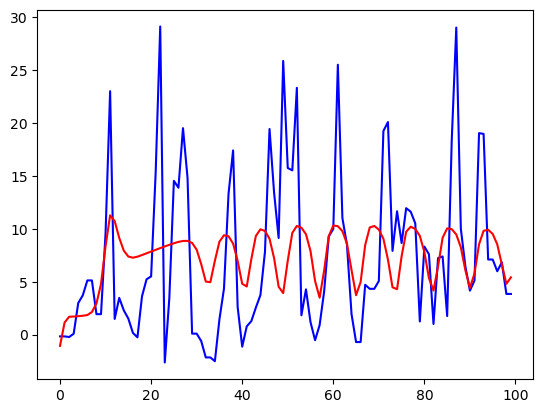

In [22]:
data_load = torch.utils.data.DataLoader(train_ds, len(train_ds), False)
for data_matrix, labels in data_load:
    accel_x = data_matrix[:, :, 0].unsqueeze(2).float()
    with torch.no_grad():
        encoded, decoded = autoencoder(accel_x)
        decoded = decoded.squeeze()
        print(encoded.size(), decoded.size())

        p1 = accel_x[33].squeeze()
        p2 = decoded[33]

        plt.plot(p1, c='b')
        plt.plot(p2, c='r')

        plt.show()




In [8]:
from src.visualizations.umap_visualizer import UMAPLatent

/Users/bhaveshkalisetti/opt/anaconda3/envs/venv/lib/python3.8/site-packages/umap/distances.py:1063: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/Users/bhaveshkalisetti/opt/anaconda3/envs/venv/lib/python3.8/site-packages/umap/distances.py:1071: NumbaDeprecationWarning: The 'nopython' keyword argument was not supplied to the 'numba.jit' decorator. The implicit default value for this argument is currently False, but it will be changed to True in Numba 0.59.0. See https://numba.readthedocs.io/en/stable/reference/deprecation.html#deprecation-of-object-mode-fall-back-behaviour-when-using-jit for details.
  @numba.jit()
/Users/bhaveshkalisetti/opt/anaconda3/envs/ven

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


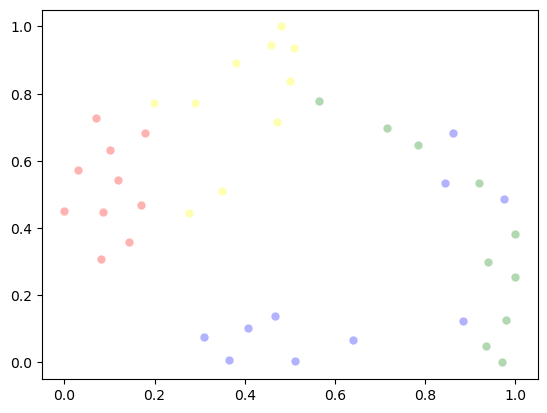

In [9]:
visualizer = UMAPLatent()
visualizer.visualize(encoded, labels, class_to_index)